Need a baseline trivial model to compare others to

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_poisson_deviance, average_precision_score, precision_recall_curve
train= pd.read_csv('claims_train.csv')
test = pd.read_csv('claims_test.csv')
#Cleaning weird values that found during cleaning
train = train[train['Exposure'] <= 1].copy()
test =test[test['Exposure']<=1].copy()

y_train_count= train['ClaimNb']
y_test=test['ClaimNb']
lambda_bar=y_train_count.mean()
y_pred_baseline= np.full_like(y_test, lambda_bar, dtype=float)

mpd_base = mean_poisson_deviance(y_test, y_pred_baseline)
mpd_base
y_true_bin= (y_test >0).astype(int)
y_true_bin[y_true_bin >0]
ap_base = average_precision_score(y_true_bin, y_pred_baseline)

print(ap_base)


0.05051967526759398


array([0.05314028, 0.05314028, 0.05314028, ..., 0.05314028, 0.05314028,
       0.05314028], shape=(135373,))

C:\Users\shere\AppData\Local\Temp\ipykernel_13304\4075990928.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df.groupby("bucket").agg(


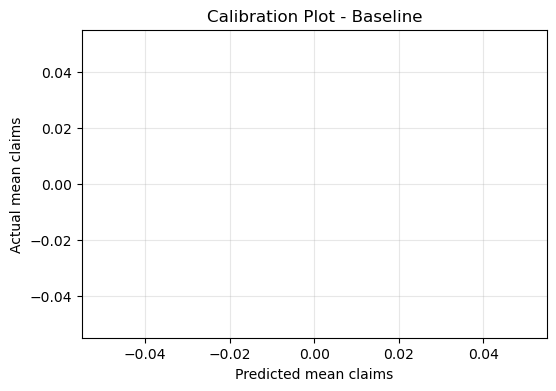

In [20]:
def calibration_plot(y_true, y_pred, model_name, bins=20):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["bucket"] = pd.qcut(df["y_pred"], bins, duplicates='drop')
    
    calib = df.groupby("bucket").agg(
        predicted=("y_pred","mean"),
        actual=("y_true","mean")
    )

    plt.figure(figsize=(6,4))
    plt.scatter(calib["predicted"], calib["actual"], label=model_name)
    max_val = max(calib["predicted"].max(), calib["actual"].max())
    plt.plot([0, max_val], [0, max_val], "r--")
    plt.xlabel("Predicted mean claims")
    plt.ylabel("Actual mean claims")
    plt.title(f"Calibration Plot - {model_name}")
    plt.grid(alpha=0.3)
    plt.show()
calibration_plot(y_test, y_pred_baseline, "Baseline")

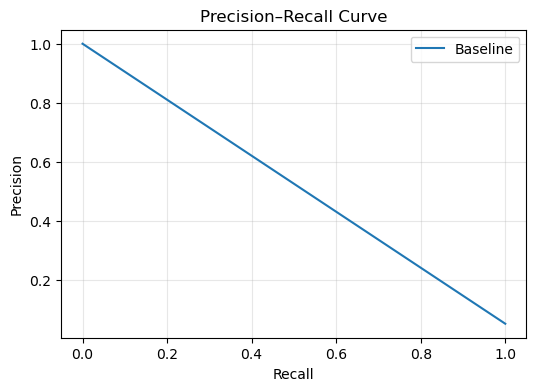

In [10]:
def pr_curve(y_true_bin, y_pred, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred)

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=model_name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
pr_curve((y_test>0).astype(int), y_pred_baseline, "Baseline")